In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt                        # For Plotting
import seaborn as sns                                  # For Plotting
from sklearn.metrics import log_loss                   # For Model Evaluation
from sklearn.model_selection import RepeatedKFold      # For Cross-Validation

In [19]:
data = pd.read_csv("dataset/Participants_Data_DCW/train.csv")

In [20]:
data.head()

,Id,Review,Components,Delivery and Customer Support,Design and Aesthetics,Dimensions,Features,Functionality,Installation,Material,Price,Quality,Usability,Polarity
0,0,For some reason everybody complains and I'm co...,0,0,0,0,0,0,0,0,0,0,1,0
1,1,"I like everything about it, great choice of sp...",0,0,0,0,1,1,0,0,0,0,0,1
2,2,Excellent ceiling fan brace. Easy to install a...,0,0,0,0,0,0,1,0,0,1,0,1
3,3,Work great easy to use . No issues at all with...,0,0,0,0,0,1,0,0,0,0,1,1
4,4,I would recommend this product because it is p...,0,0,0,0,0,0,0,0,0,1,0,1


In [21]:
data.columns

Index(['Id', 'Review', 'Components', 'Delivery and Customer Support',
       'Design and Aesthetics', 'Dimensions', 'Features', 'Functionality',
       'Installation', 'Material', 'Price', 'Quality', 'Usability',
       'Polarity'],
      dtype='object')

In [22]:
data.isnull().sum()

Id                               0
Review                           0
Components                       0
Delivery and Customer Support    0
Design and Aesthetics            0
Dimensions                       0
Features                         0
Functionality                    0
Installation                     0
Material                         0
Price                            0
Quality                          0
Usability                        0
Polarity                         0
dtype: int64

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6136 entries, 0 to 6135
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Id                             6136 non-null   int64 
 1   Review                         6136 non-null   object
 2   Components                     6136 non-null   int64 
 3   Delivery and Customer Support  6136 non-null   int64 
 4   Design and Aesthetics          6136 non-null   int64 
 5   Dimensions                     6136 non-null   int64 
 6   Features                       6136 non-null   int64 
 7   Functionality                  6136 non-null   int64 
 8   Installation                   6136 non-null   int64 
 9   Material                       6136 non-null   int64 
 10  Price                          6136 non-null   int64 
 11  Quality                        6136 non-null   int64 
 12  Usability                      6136 non-null   int64 
 13  Pol

In [24]:
data.shape

(6136, 14)

([<matplotlib.patches.Wedge at 0x158a5545d30>,
 [Text(-0.8417633550181225, 0.7081203669918233, '1'),
  Text(0.8417634169239703, -0.708120293402528, '0')],
 [Text(-0.4591436481917031, 0.38624747290463085, '1.1f%'),
  Text(0.45914368195852917, -0.3862474327650152, '1.1f%')])

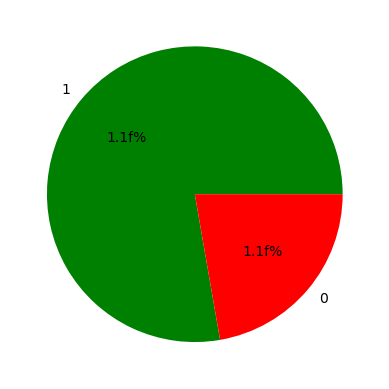

In [25]:
sentiment_count = data.Polarity.value_counts()
sentiment_type = data.Polarity.value_counts().index                # 1- Positive    0- Negative
plt.pie(sentiment_count,labels=sentiment_type, autopct='1.1f%%',colors=['green', 'red'])

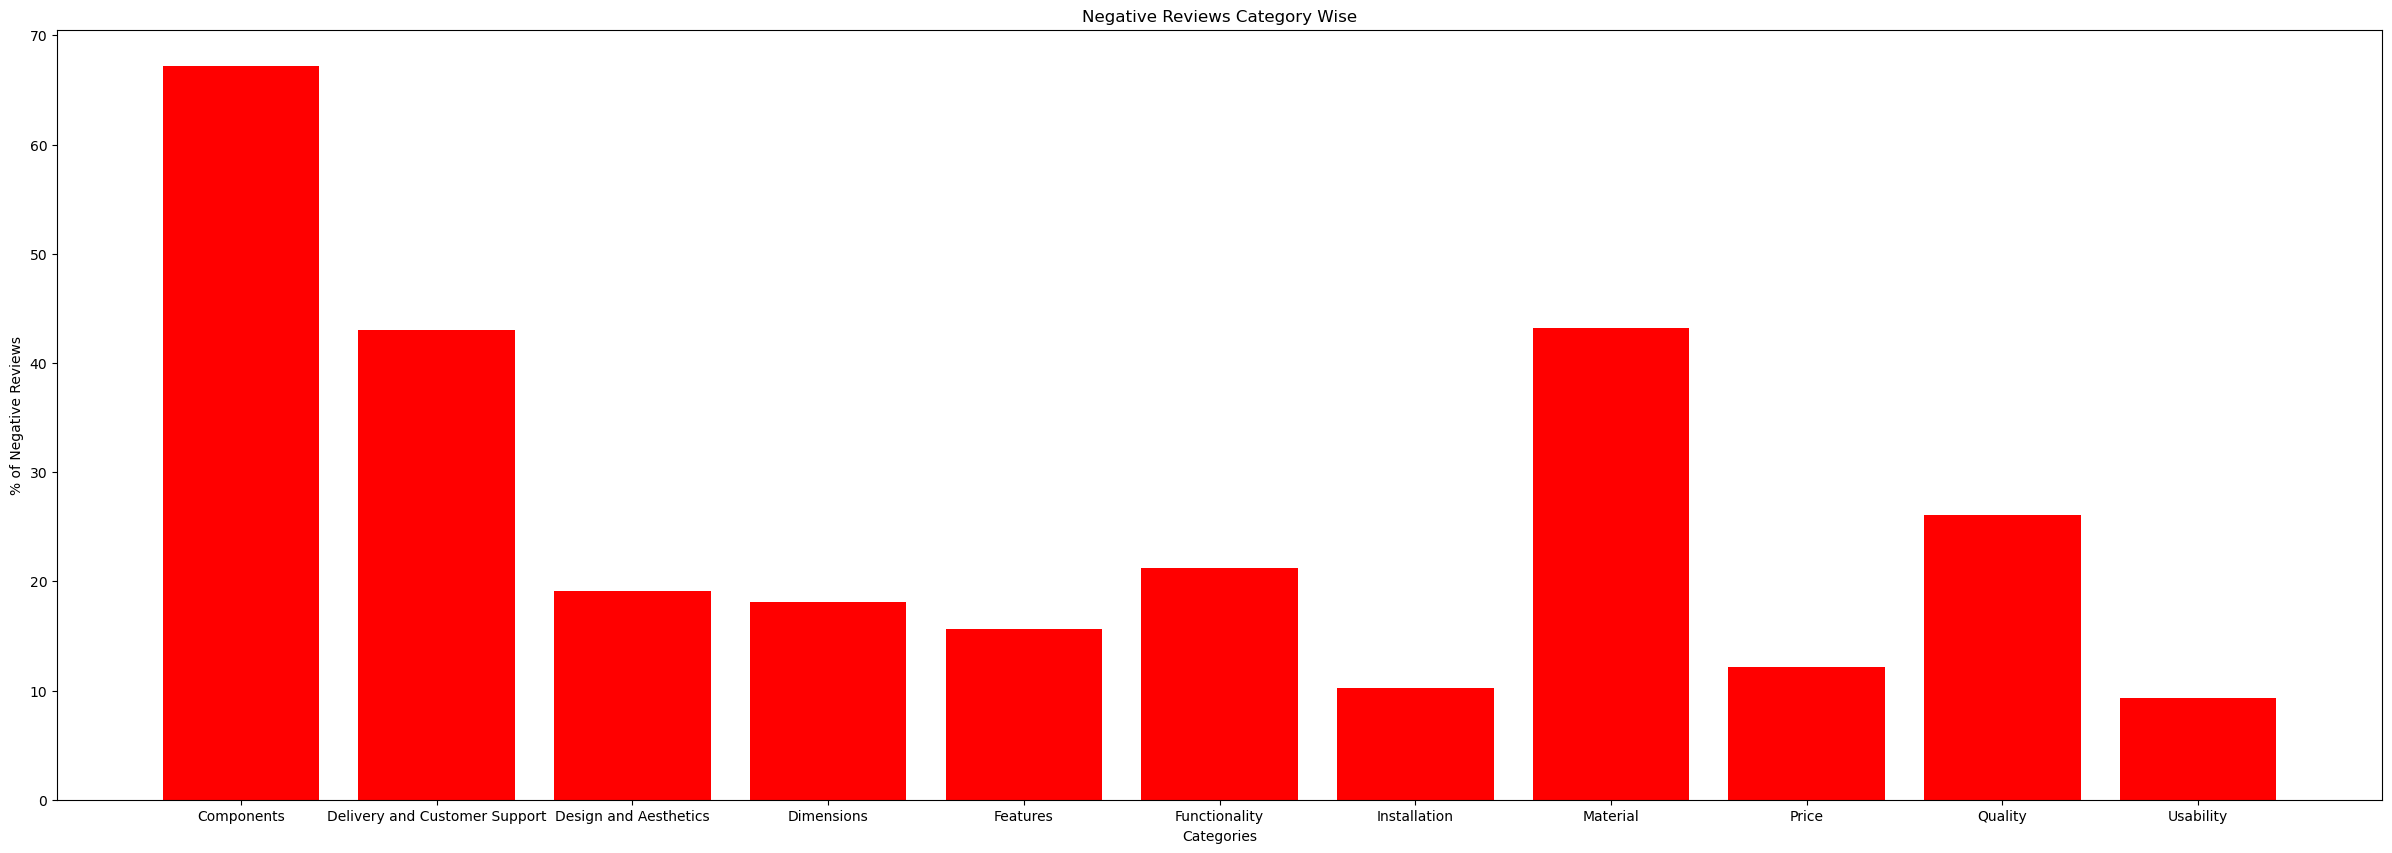

In [26]:
col = ['Components', 'Delivery and Customer Support',
       'Design and Aesthetics', 'Dimensions', 'Features', 'Functionality',
       'Installation', 'Material', 'Price', 'Quality', 'Usability']
negative_category=[]
for i in col:
    k = ((data[i].sum()-data[data[i]==1]['Polarity'].sum())/data[i].sum())*100
    negative_category.append(k)
fig = plt.figure(figsize = (30, 10))
plt.bar(col,negative_category,color ='red')
plt.xlabel("Categories")
plt.ylabel("% of Negative Reviews")
plt.title("Negative Reviews Category Wise")
plt.show()


In [27]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"'s", " ", text)
    text = re.sub(r"'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"'re", " are ", text)
    text = re.sub(r"'d", " would ", text)
    text = re.sub(r"'ll", " will ", text)
    text = text.strip(' ')

    return text
    data['Review'] = data['Review'].map(lambda com : clean_text(com))
data['Review'][0]

"For some reason everybody complains and I'm complaining now about my toilet that I just boughtFor some reason it's not ceiling from the tank to the pedestal I can't get it sealed without cracking the toilet support design for some reason I'm very unhappy with his toilet never buy American standard again"

In [28]:
#!pip install nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
data['Review'] = data['Review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
data['Review'][0]

[nltk_data] Downloading package stopwords to C:\Users\Ansuman
[nltk_data]     Mohanty\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


"For reason everybody complains I'm complaining toilet I boughtFor reason ceiling tank pedestal I can't get sealed without cracking toilet support design reason I'm unhappy toilet never buy American standard"

In [29]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import log_loss

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation

In [30]:
data = pd.read_csv("dataset/Participants_Data_DCW/train.csv")

In [31]:
data["Review"]

0       For some reason everybody complains and I'm co...
1       I like everything about it, great choice of sp...
2       Excellent ceiling fan brace. Easy to install a...
3       Work great easy to use . No issues at all with...
4       I would recommend this product because it is p...
                              ...                        
6131    Easy to install. Just be careful with the razo...
6132    Got a big pup and she had to learn about scree...
6133    We installed our Nest cam system a little over...
6134    this is a below average camera . The only thin...
6135                      So easy to install amd operate.
Name: Review, Length: 6136, dtype: object

In [32]:
y = np.array(data[
[
'Components',
'Delivery and Customer Support',
'Design and Aesthetics',
'Dimensions',
'Features',
'Functionality',
'Installation',
'Material',
'Price',
'Quality',
'Usability',
'Polarity'
]])

X = data["Review"]

In [33]:
vectorizer = TfidfVectorizer(
    min_df=20,
    ngram_range=(1,4),
    max_features=250
)

vectorizer.fit(X)

X = vectorizer.transform(X)
X = X.todense()

In [34]:
def get_model(n_inputs, n_outputs):

    model = Sequential()

    model.add(Dense(
        64,
        input_dim=n_inputs,
        activation="relu",
        kernel_initializer="he_uniform"
    ))

    model.add(Dropout(0.2))

    model.add(Dense(
        64,
        activation="relu",
        kernel_initializer="he_uniform"
    ))

    model.add(Dropout(0.2))

    model.add(Dense(n_outputs))
    model.add(Activation("sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer="adam"
    )

    return model

In [35]:
def get_model(n_inputs, n_outputs):

    model = Sequential()

    model.add(Dense(
        64,
        input_dim=n_inputs,
        activation="relu",
        kernel_initializer="he_uniform"
    ))

    model.add(Dropout(0.2))

    model.add(Dense(
        64,
        activation="relu",
        kernel_initializer="he_uniform"
    ))

    model.add(Dropout(0.2))

    model.add(Dense(n_outputs))
    model.add(Activation("sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer="adam"
    )

    return model

In [37]:
def evaluate_model(X, y):

    results_train = []
    results_test = []

    callback = tf.keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=5,
        min_delta=0.05
    )

    n_inputs = X.shape[1]
    n_outputs = y.shape[1]

    cv = RepeatedKFold(
        n_splits=10,
        n_repeats=3,
        random_state=1
    )

    for train_ix, test_ix in cv.split(X):

        X_train = X[train_ix]
        X_test = X[test_ix]

        y_train = y[train_ix]
        y_test = y[test_ix]

        model = get_model(n_inputs, n_outputs)

        model.fit(
            X_train,
            y_train,
            epochs=50,
            verbose=0,
            callbacks=[callback]
        )

        train_pred = model.predict(X_train, verbose=0)
        test_pred = model.predict(X_test, verbose=0)

        results_train.append(log_loss(y_train, train_pred))
        results_test.append(log_loss(y_test, test_pred))

    return results_train, results_test, model

In [38]:
results_train, results_test, model = evaluate_model(X, y)

c:\Users\Ansuman Mohanty\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Ansuman Mohanty\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\Ansuman Mohanty\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\Ansuman Mohanty\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model ins

In [39]:
model.save("sentiment_model.keras")

In [40]:
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [41]:
import os

print(os.path.exists("sentiment_model.keras"))
print(os.path.exists("vectorizer.pkl"))

True
True
